## Stakeholder hypothesis: age → value-risk tradeoff

**Stakeholder:** Sporting Directors / Front Office
**Their question:** How does injury risk change the investment case for
a transfer?
**Hypothesis to test:** younger players show a better value-risk
tradeoff than veterans -- i.e. younger players tend to combine *higher*
value growth with *lower* injury/workload risk.

This needs `dbt run` to have already materialized `date_of_birth` on
`player_key_map` -> `player_value_history`/`player_injury_workload` --
confirmed done, since `hypothesis_position_vs_injury_risk.ipynb` already
ran successfully against these tables. Reuses the same value-change
logic as `hypothesis_injury_recency_vs_value.ipynb` and the same
workload-adjusted risk metric as `hypothesis_position_vs_injury_risk.ipynb`,
so results are directly comparable across all three notebooks rather than
each one inventing its own yardstick.

In [1]:
import duckdb
import pandas as pd
from scipy import stats

DB_PATH = "../data/warehouse.duckdb"  # adjust if this notebook lives elsewhere

with duckdb.connect(DB_PATH, read_only=True) as con:
    value_history = con.sql("""
        SELECT player_id, canonical_name, valuation_date, market_value_in_eur
        FROM main.player_value_history
        ORDER BY player_id, valuation_date
    """).df()

    workload = con.sql("""
        SELECT player_id, date_of_birth, injury_count, total_days_missed, total_90s_played
        FROM main.player_injury_workload
    """).df()

value_history["valuation_date"] = pd.to_datetime(value_history["valuation_date"])
workload["date_of_birth"] = pd.to_datetime(workload["date_of_birth"])

print(f"{len(value_history):,} valuation snapshots, {len(workload):,} players")

32,544 valuation snapshots, 1,959 players


### Step 1 -- per-player value growth

Same logic as the recency notebook: percent change between consecutive
valuations, then collapsed to one number per player (median, not mean --
median is far less swayed by the handful of huge outlier jumps that
notebook already surfaced, e.g. breakout-debut valuations).

In [2]:
value_history = value_history.sort_values(["player_id", "valuation_date"]).reset_index(drop=True)
value_history["prev_value"] = value_history.groupby("player_id")["market_value_in_eur"].shift(1)
value_history["value_change_pct"] = (
    (value_history["market_value_in_eur"] - value_history["prev_value"]) / value_history["prev_value"]
)
value_history_changes = value_history.dropna(subset=["value_change_pct"])

player_value_growth = (
    value_history_changes.groupby("player_id")["value_change_pct"]
    .median()
    .rename("median_value_change_pct")
    .reset_index()
)

# Also grab each player's most recent valuation_date, to compute age AS OF
# when we last actually observed them -- more meaningful for a recruitment
# question ("how old is this player right now") than an arbitrary fixed date.
latest_valuation_date = (
    value_history.groupby("player_id")["valuation_date"].max().rename("latest_valuation_date").reset_index()
)

print(f"{len(player_value_growth):,} players have at least one value-change snapshot")

1,831 players have at least one value-change snapshot


### Step 2 -- per-player workload-adjusted risk

Same metric as the position notebook: injuries and days missed per 1,000
90s played, so "risk" means the same thing in both notebooks. Same
exposure floor too, and same reasoning -- a player with barely any
playing time gets an unreliable rate.

In [3]:
MIN_90S_PLAYED = 10  # ~900 minutes; keep in sync with hypothesis_position_vs_injury_risk.ipynb

n_zero_exposure = (workload["total_90s_played"] == 0).sum()
rated = workload[workload["total_90s_played"] > 0].copy()
n_below_floor = (rated["total_90s_played"] < MIN_90S_PLAYED).sum()
rated_floor = rated[rated["total_90s_played"] >= MIN_90S_PLAYED].copy()

print(f"Excluding {n_zero_exposure} player(s) with 0 recorded 90s played, "
      f"then {n_below_floor} more below {MIN_90S_PLAYED} total 90s played "
      f"({len(rated_floor):,} players remain with a usable risk rate).")

rated_floor["risk_per_1000_90s"] = rated_floor["injury_count"] / rated_floor["total_90s_played"] * 1000

Excluding 1310 player(s) with 0 recorded 90s played, then 67 more below 10 total 90s played (582 players remain with a usable risk rate).


### Step 3 -- combine into one per-player table and bucket by age

Age buckets use standard recruitment-scouting language rather than
arbitrary round numbers, so the result reads naturally for the actual
stakeholder (Sporting Directors), not just as a stats exercise.

In [4]:
combined = (
    rated_floor
    .merge(player_value_growth, on="player_id", how="inner")
    .merge(latest_valuation_date, on="player_id", how="inner")
)

combined["age_at_latest_valuation"] = (
    (combined["latest_valuation_date"] - combined["date_of_birth"]).dt.days / 365.25
)

def age_bucket(age):
    if pd.isna(age):
        return "unknown"
    elif age < 21:
        return "Under 21 (academy/breakout)"
    elif age < 25:
        return "21-24 (emerging)"
    elif age < 29:
        return "25-28 (prime)"
    elif age < 33:
        return "29-32 (established)"
    else:
        return "33+ (veteran)"

combined["age_bucket"] = combined["age_at_latest_valuation"].apply(age_bucket)
bucket_order = ["Under 21 (academy/breakout)", "21-24 (emerging)", "25-28 (prime)",
                 "29-32 (established)", "33+ (veteran)"]

print(f"{len(combined):,} players have both a value-growth number and a risk rate to compare.")

582 players have both a value-growth number and a risk rate to compare.


### Step 4 -- summarize: value growth AND risk, side by side, by age

The hypothesis is really two claims bundled together -- "younger =
higher value growth" AND "younger = lower risk" -- so both get reported
rather than collapsing them into one arbitrary combined score.

In [5]:
age_summary = (
    combined.groupby("age_bucket")
    .agg(
        n_players=("player_id", "count"),
        median_value_change_pct=("median_value_change_pct", "median"),
        median_risk_per_1000_90s=("risk_per_1000_90s", "median"),
    )
    .reindex(bucket_order)
)
age_summary["median_value_change_pct"] = (age_summary["median_value_change_pct"] * 100).round(2)
age_summary["median_risk_per_1000_90s"] = age_summary["median_risk_per_1000_90s"].round(2)
age_summary

,n_players,median_value_change_pct,median_risk_per_1000_90s
age_bucket,,,
Under 21 (academy/breakout),4,0.00,0.00
21-24 (emerging),83,7.14,2.49
25-28 (prime),165,0.00,3.97
29-32 (established),153,0.00,3.22
33+ (veteran),177,0.00,5.95


### Step 5 -- is either pattern statistically real?

Two separate Kruskal-Wallis tests (same reasoning as the position
notebook) -- one for value growth across age buckets, one for risk
across age buckets. Kept separate on purpose: the hypothesis could turn
out true for one half and not the other, and collapsing them into a
single test would hide that.

In [6]:
value_groups = [g["median_value_change_pct"].dropna().values for _, g in combined.groupby("age_bucket") if _ != "unknown"]
risk_groups = [g["risk_per_1000_90s"].dropna().values for _, g in combined.groupby("age_bucket") if _ != "unknown"]

h_value, p_value_growth = stats.kruskal(*value_groups)
h_risk, p_value_risk = stats.kruskal(*risk_groups)

print(f"Value growth across age buckets: H={h_value:.2f}, p={p_value_growth:.4f} "
      f"({'significant' if p_value_growth < 0.05 else 'not significant'} at p<0.05)")
print(f"Risk rate across age buckets:    H={h_risk:.2f}, p={p_value_risk:.4f} "
      f"({'significant' if p_value_risk < 0.05 else 'not significant'} at p<0.05)")

Value growth across age buckets: H=95.27, p=0.0000 (significant at p<0.05)
Risk rate across age buckets:    H=34.57, p=0.0000 (significant at p<0.05)


### Step 6 -- visualize both

C:\Users\mahmo\AppData\Local\Temp\ipykernel_28264\1502969519.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(value_plot_data, labels=bucket_order, showfliers=False)
C:\Users\mahmo\AppData\Local\Temp\ipykernel_28264\1502969519.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(risk_plot_data, labels=bucket_order, showfliers=False)


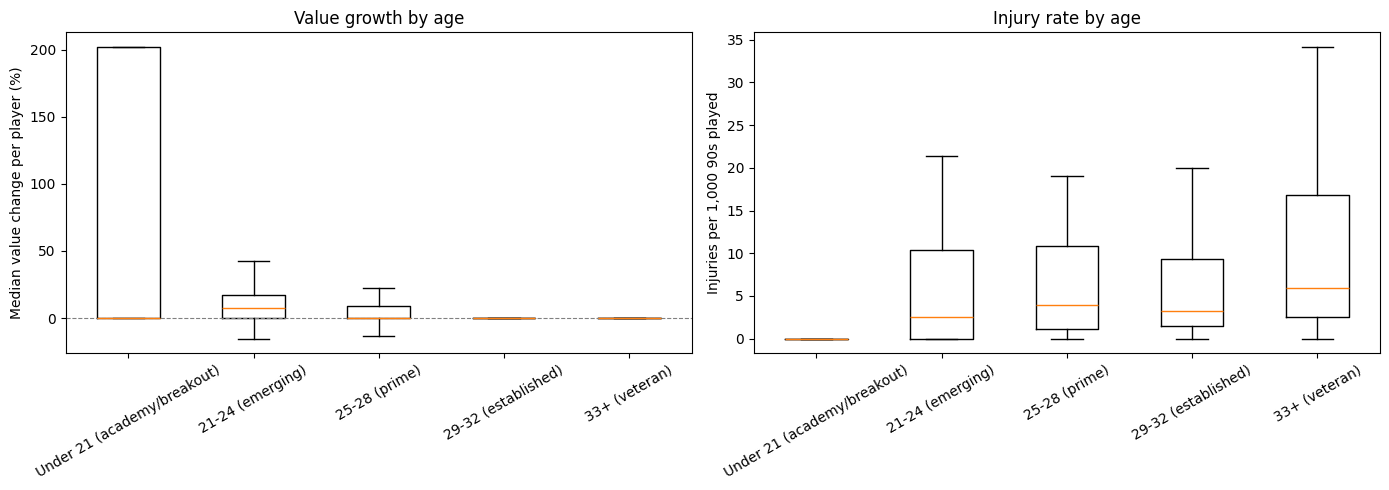

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

value_plot_data = [combined.loc[combined["age_bucket"] == b, "median_value_change_pct"] * 100 for b in bucket_order]
axes[0].boxplot(value_plot_data, labels=bucket_order, showfliers=False)
axes[0].axhline(0, color="grey", linewidth=0.8, linestyle="--")
axes[0].set_ylabel("Median value change per player (%)")
axes[0].set_title("Value growth by age")
axes[0].tick_params(axis="x", rotation=30)

risk_plot_data = [combined.loc[combined["age_bucket"] == b, "risk_per_1000_90s"] for b in bucket_order]
axes[1].boxplot(risk_plot_data, labels=bucket_order, showfliers=False)
axes[1].set_ylabel("Injuries per 1,000 90s played")
axes[1].set_title("Injury rate by age")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### Caveats worth stating explicitly in the writeup

- `median_value_change_pct` is the median across each player's *own*
  valuation history, which can be a mix of very few and very many
  snapshots per player -- a player with only 2 valuations contributes
  the same weight to the age-bucket median as one with 15.
- Same breakout-debut effect flagged in the recency notebook could still
  be inflating young players' value growth specifically (younger players
  are exactly who has a low starting valuation) -- worth checking this
  age-bucket result against that notebook's `PREV_VALUE_FLOOR`-filtered
  version before presenting "younger = more value growth" as clean.
- Age is computed as of each player's *most recent* valuation date, not
  a single fixed date -- so players are compared "as of when we last saw
  them", not all on the same calendar day.
- Same FBref coverage caveat as the position notebook: total_90s_played
  only reflects Premier League seasons 2017-2024, so recent signings or
  players who weren't at a PL club during that window may be
  underrepresented in the risk side of this comparison.

### Step 7 -- export for Tableau

Row-level (one row per player), not the aggregated `age_summary` table --
Tableau's box-and-whisker mark needs the individual per-player values to
compute its own quartiles, the same way matplotlib's `boxplot()` did
above. `age_bucket_order` is included purely so Tableau can sort the age
buckets correctly (youngest to oldest) instead of alphabetically, via
Sort -> By Field -> age_bucket_order on the age_bucket pill. Written to
`data/processed/`, alongside the project's other Tableau-ready extracts.

In [8]:
import os

# canonical_name isn't in `combined` (the workload query never selected it) --
# pull it from `value_history` instead, which already has it from Step 1.
player_names = value_history[["player_id", "canonical_name"]].drop_duplicates("player_id")

export_cols = combined.merge(player_names, on="player_id", how="left")[[
    "player_id", "canonical_name", "age_bucket",
    "age_at_latest_valuation", "median_value_change_pct", "risk_per_1000_90s",
]].copy()
export_cols["median_value_change_pct"] = (export_cols["median_value_change_pct"] * 100).round(2)
export_cols["risk_per_1000_90s"] = export_cols["risk_per_1000_90s"].round(2)
export_cols["age_at_latest_valuation"] = export_cols["age_at_latest_valuation"].round(1)

bucket_order_map = {b: i for i, b in enumerate(bucket_order)}
export_cols["age_bucket_order"] = export_cols["age_bucket"].map(bucket_order_map)

os.makedirs("../data/processed", exist_ok=True)
export_path = "../data/processed/age_risk_tradeoff.csv"
export_cols.to_csv(export_path, index=False)
print(f"Wrote {len(export_cols):,} rows to {export_path}")
export_cols.head()

Wrote 582 rows to ../data/processed/age_risk_tradeoff.csv


,player_id,canonical_name,age_bucket,age_at_latest_valuation,median_value_change_pct,risk_per_1000_90s,age_bucket_order
0,332705,Tyler Adams,25-28 (prime),27.3,5.56,19.00,2
1,214928,Kean Bryan,25-28 (prime),27.0,0.00,27.58,2
2,45861,Ryan Shawcross,33+ (veteran),34.1,0.00,19.68,4
3,511550,Ellis Simms,21-24 (emerging),22.8,75.00,35.89,1
4,177907,Harry Maguire,33+ (veteran),33.2,0.00,1.27,4
